# Low-Dose CT Simulation and Robustness Evaluation
This notebook implements **Section 2.6 and 2.7** of the project proposal:
1. Synthesizing Low-Dose CT (LDCT) images from the standard-dose CT test set using a noise model.
2. Evaluating the pre-trained model's robustness across different simulated degradation levels.

We use the exactly identical test split (by patient ID) as defined in `nn-project-03-training.ipynb` to prevent data leakage.

In [22]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.model_selection import train_test_split

# 1. Setup Kaggle paths and load the correct TEST split
DATA_DIR = "/kaggle/input/datasets/mdclakmal/lidc-patches-small-ldct/lidc_patches_small-V2.0/lidc_patches_small"
meta_path = os.path.join(DATA_DIR, "patch_meta.csv")

if os.path.exists(meta_path):
 meta_df = pd.read_csv(meta_path)
 patients = sorted(meta_df["patient_id"].unique())
 
 # Exactly replicate the training split to avoid data leakage
 rng = np.random.RandomState(42)
 train_p, temp_p = train_test_split(patients, test_size=0.30, random_state=rng, shuffle=True)
 val_p, test_p = train_test_split(temp_p, test_size=0.50, random_state=rng, shuffle=True)
 
 test_df = meta_df[meta_df["patient_id"].isin(test_p)].copy()
 print(f"Loaded {len(test_df)} patches for Testing.")
else:
 print(f"Warning: Meta CSV not found at {meta_path}. Please check your dataset path.")

Loaded 81 patches for Testing.


## 2. Low-Dose CT Noise Simulation
We simulate the signal reduction in CT by adding Gaussian noise. In reality, CT noise is a mix of Poisson (quantum) and Gaussian (electronic) noises, but additive Gaussian noise scaled by the dose reduction is a standard simplification.

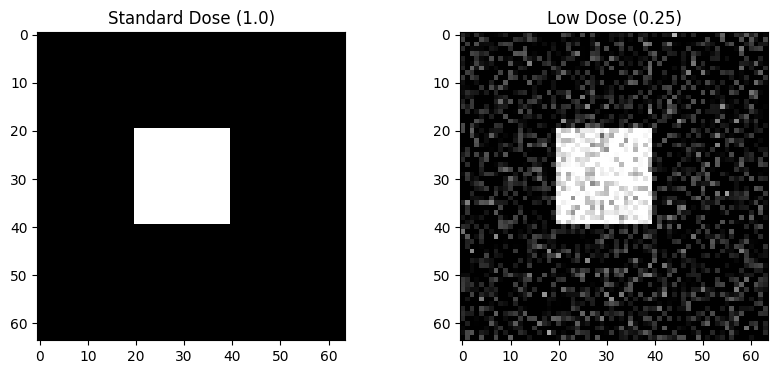

In [23]:
def add_ct_noise(image, dose_level):
    """
    Simulates Low-Dose CT by adding noise.
    dose_level: 1.0 (Standard), 0.75, 0.50, 0.25, etc.
    """
    if dose_level >= 1.0:
        return image
    
    # Noise variance is inversely proportional to dose level
    # These parameters can be tuned to match clinical LDCT characteristics
    noise_variance = 0.05 * (1.0 - dose_level)
    noise_sigma = np.sqrt(noise_variance)
    
    gaussian_noise = np.random.normal(0, noise_sigma, image.shape)
    noisy_image = image + gaussian_noise
    
    # Re-normalize to original range (assuming 0 to 1 for network input)
    return np.clip(noisy_image, 0.0, 1.0)

# Test the function
sample = np.zeros((64, 64))
sample[20:40, 20:40] = 1.0
noisy_sample = add_ct_noise(sample, 0.25)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.title("Standard Dose (1.0)")
plt.imshow(sample, cmap='gray')
plt.subplot(1, 2, 2)
plt.title("Low Dose (0.25)")
plt.imshow(noisy_sample, cmap='gray')
plt.show()

## 3. Robustness Evaluation
Load the saved model and evaluate it on the test set across multiple dose levels.

In [24]:
 import torch.nn as nn
 import torch.nn.functional as F
 from tqdm import tqdm
 import os

 # --- MUST REDEFINE THE ARCHITECTURE SO PICKLE CAN FIND IT ---
 class DoubleConv(nn.Module):
     def __init__(self, in_ch, out_ch):
         super().__init__()
         self.net = nn.Sequential(
             nn.Conv2d(in_ch, out_ch, 3, padding=1),
             nn.BatchNorm2d(out_ch),
             nn.ReLU(inplace=True),
             nn.Conv2d(out_ch, out_ch, 3, padding=1),
             nn.BatchNorm2d(out_ch),
             nn.ReLU(inplace=True),
         )
     def forward(self, x):
         return self.net(x)

 class UNet2D(nn.Module):
     def __init__(self, in_ch=1, out_ch=1, base=32):
         super().__init__()
         self.down1 = DoubleConv(in_ch, base)
         self.down2 = DoubleConv(base, base*2)
         self.down3 = DoubleConv(base*2, base*4)
         self.down4 = DoubleConv(base*4, base*8)
         self.pool = nn.MaxPool2d(2)
         self.bottleneck = DoubleConv(base*8, base*16)
         self.up4 = nn.ConvTranspose2d(base*16, base*8, 2, stride=2)
         self.conv4 = DoubleConv(base*16, base*8)
         self.up3 = nn.ConvTranspose2d(base*8, base*4, 2, stride=2)
         self.conv3 = DoubleConv(base*8, base*4)
         self.up2 = nn.ConvTranspose2d(base*4, base*2, 2, stride=2)
         self.conv2 = DoubleConv(base*4, base*2)
         self.up1 = nn.ConvTranspose2d(base*2, base, 2, stride=2)
         self.conv1 = DoubleConv(base*2, base)
         self.outc = nn.Conv2d(base, out_ch, 1)

     def forward(self, x):
         c1 = self.down1(x)
         p1 = self.pool(c1)
         c2 = self.down2(p1)
         p2 = self.pool(c2)
         c3 = self.down3(p2)
         p3 = self.pool(c3)
         c4 = self.down4(p3)
         p4 = self.pool(c4)
         bn = self.bottleneck(p4)
         u4 = self.up4(bn)
         u4 = torch.cat([u4, c4], dim=1)
         c4 = self.conv4(u4)
         u3 = self.up3(c4)
         u3 = torch.cat([u3, c3], dim=1)
         c3 = self.conv3(u3)
         u2 = self.up2(c3)
         u2 = torch.cat([u2, c2], dim=1)
         c2 = self.conv2(u2)
         u1 = self.up1(c2)
         u1 = torch.cat([u1, c1], dim=1)
         c1 = self.conv1(u1)
         logits = self.outc(c1)
         return logits

 # --- LOAD MODEL ---
 device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
 model_path = "/kaggle/input/models/mdclakmal/unetmodel/pytorch/default/1/unet_model_full.pth"

 print(f"Loading full model from: {model_path}")
 model = torch.load(model_path, map_location=device, weights_only=False)
 model.eval()
 print("Model loaded successfully!")

 # --- ROBUSTNESS EVALUATION LOOP ---
 def compute_dice(pred, target):
     smooth = 1e-6
     pred = (pred > 0.5).float()
     intersection = (pred * target).sum()
     return (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)

 dose_levels = [1.0, 0.95, 0.9, 0.85, 0.8, 0.75, 0.7, 0.65, 0.6, 0.55, 0.5, 0.45, 0.4, 0.35, 0.3, 0.25, 0.2, 0.15, 0.1, 0.05, 0.0]
 dice_results = {d: [] for d in dose_levels}

 print("Running inference over dose levels...")
 with torch.no_grad():
     for idx, row in tqdm(test_df.iterrows(), total=len(test_df)):
         # Use exact column names from patch_meta.csv
         img_filename = row['patch_file']
         mask_filename = row['mask_file']

         # Build paths using the directories found in Kaggle input
         img_path = os.path.join(DATA_DIR, 'patches', img_filename)
         mask_path = os.path.join(DATA_DIR, 'masks', mask_filename)

         try:
             img = np.load(img_path)
             mask = np.load(mask_path)
         except FileNotFoundError:
             continue

         for dose in dose_levels:
             noisy_img = add_ct_noise(img, dose)
             tensor_img = torch.tensor(noisy_img).unsqueeze(0).unsqueeze(0).float().to(device)
             tensor_mask = torch.tensor(mask).unsqueeze(0).unsqueeze(0).float().to(device)

             logits = model(tensor_img)
             pred = torch.sigmoid(logits)

             dice = compute_dice(pred, tensor_mask)
             dice_results[dose].append(dice.item())

 # --- DISPLAY RESULTS ---
 print("\n--- Final Robustness Results ---")
 for dose in dose_levels:
     mean_dice = np.mean(dice_results[dose]) if dice_results[dose] else 0.0
     print(f"Dose Level: {dose*100}% | Mean Dice Score: {mean_dice:.4f}")

Loading full model from: /kaggle/input/models/mdclakmal/unetmodel/pytorch/default/1/unet_model_full.pth
Model loaded successfully!
Running inference over dose levels...


100%|██████████| 81/81 [00:06<00:00, 12.44it/s]


--- Final Robustness Results ---
Dose Level: 100.0% | Mean Dice Score: 0.8786
Dose Level: 95.0% | Mean Dice Score: 0.0628
Dose Level: 90.0% | Mean Dice Score: 0.0637
Dose Level: 85.0% | Mean Dice Score: 0.0596
Dose Level: 80.0% | Mean Dice Score: 0.0545
Dose Level: 75.0% | Mean Dice Score: 0.0496
Dose Level: 70.0% | Mean Dice Score: 0.0454
Dose Level: 65.0% | Mean Dice Score: 0.0438
Dose Level: 60.0% | Mean Dice Score: 0.0414
Dose Level: 55.00000000000001% | Mean Dice Score: 0.0390
Dose Level: 50.0% | Mean Dice Score: 0.0380
Dose Level: 45.0% | Mean Dice Score: 0.0364
Dose Level: 40.0% | Mean Dice Score: 0.0353
Dose Level: 35.0% | Mean Dice Score: 0.0344
Dose Level: 30.0% | Mean Dice Score: 0.0344
Dose Level: 25.0% | Mean Dice Score: 0.0332
Dose Level: 20.0% | Mean Dice Score: 0.0324
Dose Level: 15.0% | Mean Dice Score: 0.0323
Dose Level: 10.0% | Mean Dice Score: 0.0316
Dose Level: 5.0% | Mean Dice Score: 0.0306
Dose Level: 0.0% | Mean Dice Score: 0.0309


In [25]:
# @title step_artifacts
num_fig = "1" # @param {type:"string"}
step = 'ModelRobustnessEvaluation'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary", "ModelRobustnessEvaluation"] {type:"string"}
# Uncomment the following line and replace `fig` with your figure object if you want to upload the plot to GCS.
# upload_plt_to_gcs(num_fig, step, fig)

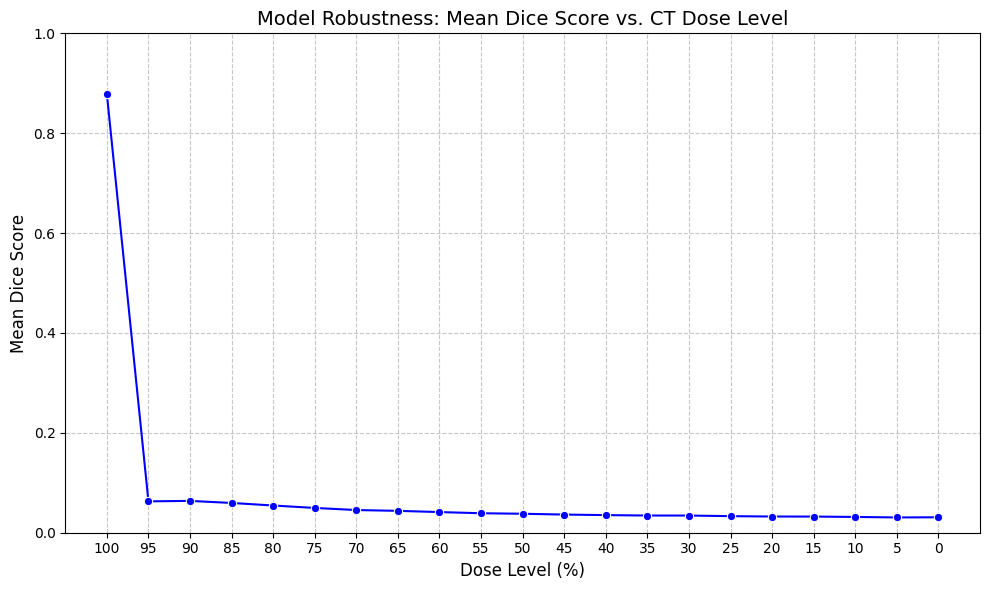

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting
plot_data = {
    'Dose Level (%)': [d * 100 for d in dice_results.keys()],
    'Mean Dice Score': [np.mean(dice_results[d]) if dice_results[d] else 0.0 for d in dice_results.keys()]
}

plot_df = pd.DataFrame(plot_data)

# Create the plot
fig = plt.figure(figsize=(10, 6))
sns.lineplot(
    x='Dose Level (%)',
    y='Mean Dice Score',
    data=plot_df,
    marker='o',
    color='blue'
)

plt.title('Model Robustness: Mean Dice Score vs. CT Dose Level', fontsize=14)
plt.xlabel('Dose Level (%)', fontsize=12)
plt.ylabel('Mean Dice Score', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Set ticks and invert x-axis so it starts at 100
plt.xticks(plot_df['Dose Level (%)'].unique())
plt.gca().invert_xaxis()

plt.ylim(0, 1.0)
plt.tight_layout()
plt.show()